# BLG481E – AI Accelerators: Project 1
## Unsupervised Learning with AutoEncoders on MNIST

---

**Team Members:**
- Member 1 (Team Leader)
- Member 2
- Member 3

---

### Objective
In this project, we implement a **Convolutional Autoencoder** to perform unsupervised learning on the MNIST dataset. The autoencoder compresses input images into a low-dimensional latent space and reconstructs them. We then apply **K-Means clustering** on the latent representations and evaluate using PMS, AD, AVC, and TD metrics.

## 1. Setup & Imports

In [1]:
# Install required packages (uncomment if running on Colab/Kaggle/fresh environment)
# !pip install torch torchvision numpy matplotlib seaborn scikit-learn scipy
import sys
print(sys.executable)


c:\Python313\python.exe


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Data Loading & Preprocessing

We load the MNIST dataset using `torchvision.datasets.MNIST`. The pixel values are normalized to `[0, 1]` using `transforms.ToTensor()` which also converts PIL images to tensors with shape `(C, H, W)`.

In [3]:
# Hyperparameters
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
EPOCHS = 30
LATENT_DIM = 10

# Data transforms: ToTensor normalizes pixel values to [0, 1]
transform = transforms.ToTensor()

# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Image shape: {train_dataset[0][0].shape}')
print(f'Number of classes: {len(train_dataset.classes)}')

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Number of classes: 10


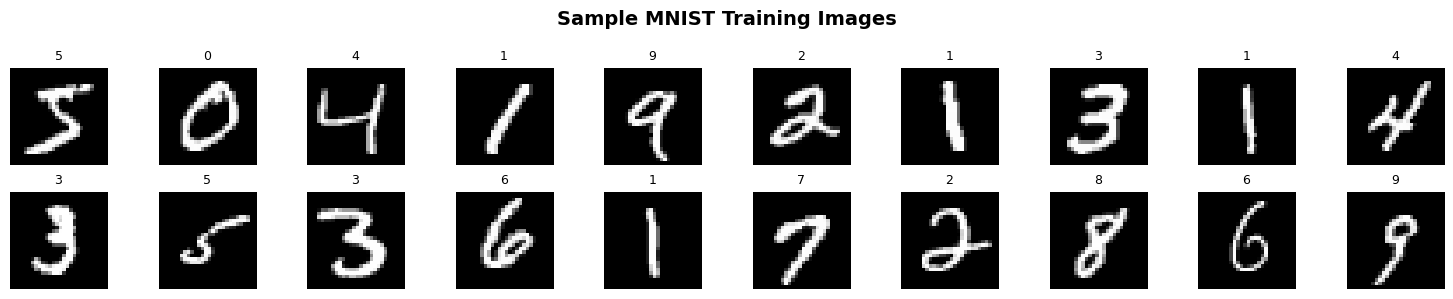

In [4]:
# Visualize some training samples
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('Sample MNIST Training Images', fontsize=14, fontweight='bold')
for i in range(20):
    ax = axes[i // 10, i % 10]
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(label), fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Autoencoder Architecture

We use a **Convolutional Autoencoder** for better spatial feature extraction compared to a fully-connected autoencoder.

### Architecture Overview

**Encoder:**
- Conv2d(1 → 32, 3x3, pad=1) → BatchNorm → ReLU → MaxPool2d(2) : output 32x14x14
- Conv2d(32 → 64, 3x3, pad=1) → BatchNorm → ReLU → MaxPool2d(2) : output 64x7x7
- Conv2d(64 → 128, 3x3, stride=2, pad=1) → BatchNorm → ReLU : output 128x4x4
- Flatten → Linear(2048 → 32)

**Decoder:**
- Linear(32 → 2048) → ReLU → Reshape to 128x4x4
- ConvTranspose2d(128 → 64, 3x3, stride=2) → BatchNorm → ReLU : output 64x7x7
- ConvTranspose2d(64 → 32, 3x3, stride=2) → BatchNorm → ReLU : output 32x14x14
- ConvTranspose2d(32 → 1, 3x3, stride=2) → Sigmoid : output 1x28x28

**Latent space dimension:** 32

In [5]:
class Encoder(nn.Module):
    """Convolutional encoder that maps 28x28 images to a latent vector."""
    def __init__(self, latent_dim=32):
        super().__init__()
        self.conv_layers = nn.Sequential(
            # Block 1: 1x28x28 -> 32x14x14
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),
            
            # Block 2: 32x14x14 -> 64x7x7
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, stride=2),
            
            # Block 3: 64x7x7 -> 128x4x4
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        # 128 * 4 * 4 = 2048 -> latent_dim
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128 * 4 * 4, latent_dim)
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        z = self.fc(x)
        return z


class Decoder(nn.Module):
    """Convolutional decoder that maps a latent vector back to 28x28 images."""
    def __init__(self, latent_dim=32):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 4 * 4),
            nn.ReLU(inplace=True)
        )
        self.deconv_layers = nn.Sequential(
            # 128x4x4 -> 64x7x7
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            # 64x7x7 -> 32x14x14
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            # 32x14x14 -> 1x28x28
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # Output in [0, 1] to match normalized input
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 4, 4)
        x = self.deconv_layers(x)
        return x


class ConvAutoencoder(nn.Module):
    """Convolutional Autoencoder combining encoder and decoder."""
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
    
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon
    
    def encode(self, x):
        """Get latent representation."""
        return self.encoder(x)


# Instantiate model
model = ConvAutoencoder(latent_dim=LATENT_DIM).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

ConvAutoencoder(
  (encoder): Encoder(
    (conv_layers): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
    )
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (fc): Linear(in_features=2048, out_features=10, bias=True)
  )
  (decoder): Decoder(
    (fc): Sequentia

In [6]:
# Verify shapes with a dummy input
dummy = torch.randn(1, 1, 28, 28).to(device)
with torch.no_grad():
    z_dummy = model.encode(dummy)
    recon_dummy = model(dummy)
print(f'Input shape:   {dummy.shape}')
print(f'Latent shape:  {z_dummy.shape}')
print(f'Output shape:  {recon_dummy.shape}')
assert recon_dummy.shape == dummy.shape, 'Output shape mismatch!'
print('Shape verification passed!')

Input shape:   torch.Size([1, 1, 28, 28])
Latent shape:  torch.Size([1, 10])
Output shape:  torch.Size([1, 1, 28, 28])
Shape verification passed!


## 4. Training the Autoencoder

We train using **Mean Squared Error (MSE)** loss as specified. We use the **Adam** optimizer with learning rate scheduling via `ReduceLROnPlateau` for adaptive convergence.

In [7]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Training loop
train_losses = []
val_losses = []

print(f'Training for {EPOCHS} epochs...')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    running_train_loss = 0.0
    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)
        
        # Forward pass
        reconstructed = model(images)
        loss = criterion(reconstructed, images)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
    
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # --- Validation ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            reconstructed = model(images)
            loss = criterion(reconstructed, images)
            running_val_loss += loss.item() * images.size(0)
    
    epoch_val_loss = running_val_loss / len(test_dataset)
    val_losses.append(epoch_val_loss)
    
    # Step scheduler
    scheduler.step(epoch_val_loss)
    
    # Print progress
    current_lr = optimizer.param_groups[0]['lr']
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:>2}/{EPOCHS}]  '
              f'Train Loss: {epoch_train_loss:.6f}  '
              f'Val Loss: {epoch_val_loss:.6f}  '
              f'LR: {current_lr:.2e}')

print('=' * 60)
print(f'Final Train Loss: {train_losses[-1]:.6f}')
print(f'Final Val Loss:   {val_losses[-1]:.6f}')

Training for 30 epochs...
Epoch [ 1/30]  Train Loss: 0.037122  Val Loss: 0.018851  LR: 1.00e-03
Epoch [ 5/30]  Train Loss: 0.012957  Val Loss: 0.012538  LR: 1.00e-03
Epoch [10/30]  Train Loss: 0.011548  Val Loss: 0.011880  LR: 1.00e-03
Epoch [15/30]  Train Loss: 0.010951  Val Loss: 0.011065  LR: 1.00e-03
Epoch [20/30]  Train Loss: 0.010603  Val Loss: 0.010754  LR: 1.00e-03
Epoch [25/30]  Train Loss: 0.010398  Val Loss: 0.010982  LR: 1.00e-03
Epoch [30/30]  Train Loss: 0.010228  Val Loss: 0.010367  LR: 1.00e-03
Final Train Loss: 0.010228
Final Val Loss:   0.010367


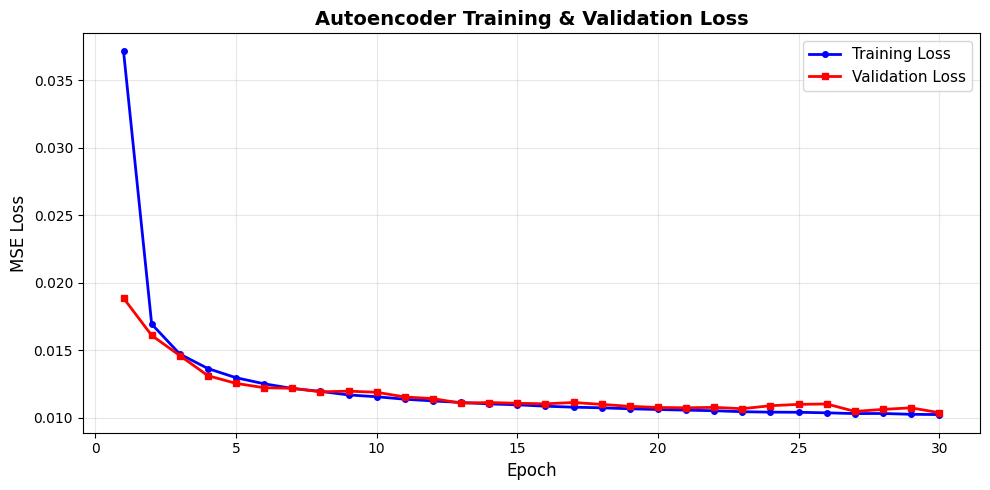

In [8]:
# Plot loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, 'b-o', label='Training Loss', markersize=4, linewidth=2)
plt.plot(range(1, EPOCHS + 1), val_losses, 'r-s', label='Validation Loss', markersize=4, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Autoencoder Training & Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Reconstruction Visualization

We visualize the original test images alongside their reconstructions to assess the quality of the autoencoder.

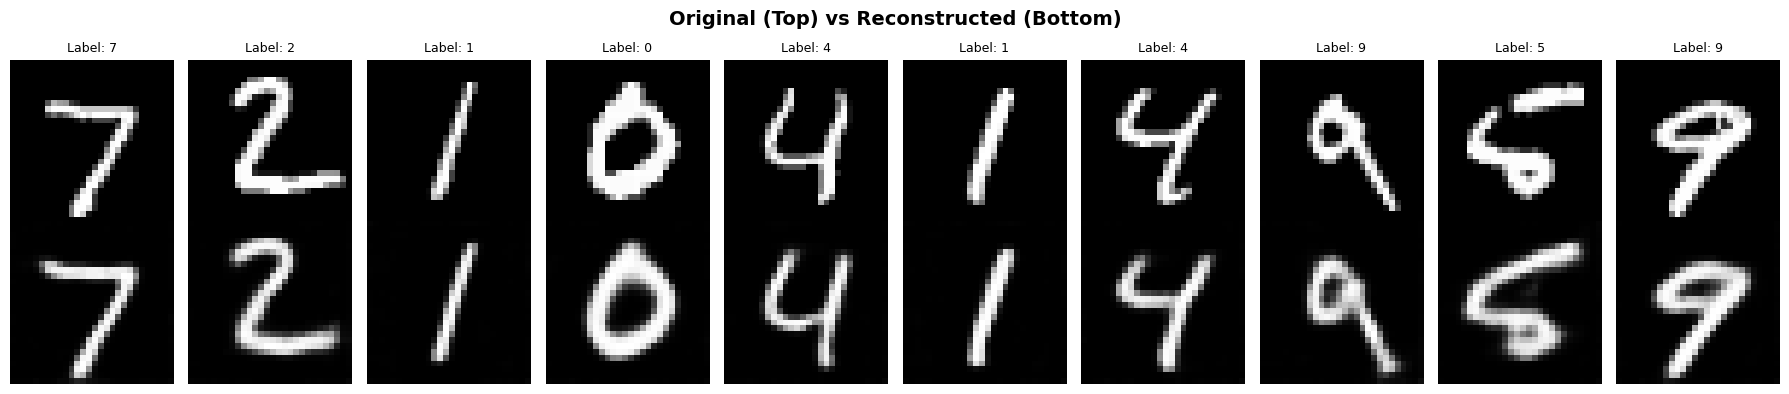

Per-image MSE for displayed samples:
  Image 0 (digit 7): MSE = 0.003623
  Image 1 (digit 2): MSE = 0.010554
  Image 2 (digit 1): MSE = 0.001992
  Image 3 (digit 0): MSE = 0.009423
  Image 4 (digit 4): MSE = 0.008097
  Image 5 (digit 1): MSE = 0.001372
  Image 6 (digit 4): MSE = 0.013852
  Image 7 (digit 9): MSE = 0.011879
  Image 8 (digit 5): MSE = 0.021029
  Image 9 (digit 9): MSE = 0.008354


In [9]:
# Get a batch of test images
model.eval()
test_images, test_labels = next(iter(test_loader))
test_images_gpu = test_images.to(device)

with torch.no_grad():
    reconstructed = model(test_images_gpu).cpu()

# Visualize original vs reconstructed
n_display = 10
fig, axes = plt.subplots(2, n_display, figsize=(18, 4))
fig.suptitle('Original (Top) vs Reconstructed (Bottom)', fontsize=14, fontweight='bold')

for i in range(n_display):
    # Original
    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'Label: {test_labels[i].item()}', fontsize=9)
    axes[0, i].axis('off')
    
    # Reconstructed
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Compute per-image MSE for displayed samples
per_image_mse = ((test_images[:n_display] - reconstructed[:n_display]) ** 2).mean(dim=[1, 2, 3])
print(f'Per-image MSE for displayed samples:')
for i in range(n_display):
    print(f'  Image {i} (digit {test_labels[i].item()}): MSE = {per_image_mse[i]:.6f}')

## 6. Latent Space Visualization

We extract the latent representations for the entire test set and visualize them using two dimensionality reduction techniques:
- **PCA**: Preserves global structure, fast computation
- **t-SNE**: Preserves local neighborhood structure, better for cluster visualization

In [10]:
# Extract latent representations for the entire test set
model.eval()
all_latent = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        z = model.encode(images)
        all_latent.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

latent_vectors = np.concatenate(all_latent, axis=0)
true_labels = np.concatenate(all_labels, axis=0)

print(f'Latent vectors shape: {latent_vectors.shape}')
print(f'Labels shape: {true_labels.shape}')

Latent vectors shape: (10000, 10)
Labels shape: (10000,)


In [11]:
# PCA reduction to 2D
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_vectors)
print(f'PCA explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total explained variance: {pca.explained_variance_ratio_.sum():.4f}')

# t-SNE reduction to 2D
print('\nComputing t-SNE (this may take a minute)...')
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, learning_rate='auto', init='pca')
latent_tsne = tsne.fit_transform(latent_vectors)
print('t-SNE completed.')

PCA explained variance ratio: [0.19506823 0.15950283]
Total explained variance: 0.3546

Computing t-SNE (this may take a minute)...
t-SNE completed.


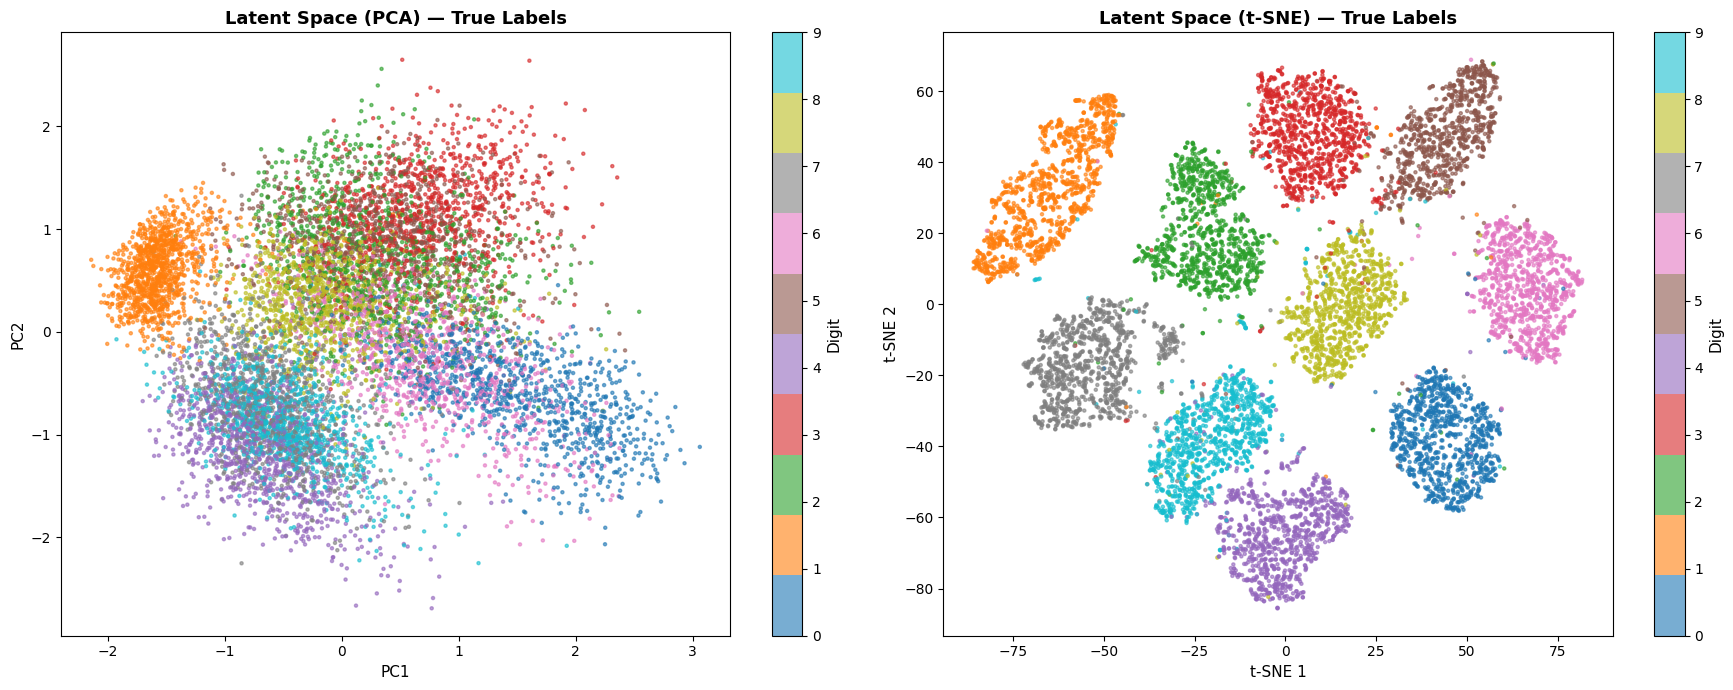

In [12]:
# Visualization of latent space (colored by true labels)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Define colors
cmap = plt.cm.get_cmap('tab10', 10)

# PCA plot
scatter1 = axes[0].scatter(latent_pca[:, 0], latent_pca[:, 1], 
                           c=true_labels, cmap=cmap, s=5, alpha=0.6)
axes[0].set_title('Latent Space (PCA) — True Labels', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
cbar1 = plt.colorbar(scatter1, ax=axes[0], ticks=range(10))
cbar1.set_label('Digit', fontsize=11)

# t-SNE plot
scatter2 = axes[1].scatter(latent_tsne[:, 0], latent_tsne[:, 1], 
                           c=true_labels, cmap=cmap, s=5, alpha=0.6)
axes[1].set_title('Latent Space (t-SNE) — True Labels', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1', fontsize=11)
axes[1].set_ylabel('t-SNE 2', fontsize=11)
cbar2 = plt.colorbar(scatter2, ax=axes[1], ticks=range(10))
cbar2.set_label('Digit', fontsize=11)

plt.tight_layout()
plt.show()

## 7. K-Means Clustering

We apply K-Means with **k=10** (matching the number of MNIST digit classes) on the latent representations. We use the **Hungarian algorithm** (linear sum assignment) to find the optimal mapping between cluster IDs and true digit labels.

In [13]:
# K-Means clustering on latent space
kmeans = KMeans(n_clusters=10, random_state=SEED, n_init=20, max_iter=500)
cluster_assignments = kmeans.fit_predict(latent_vectors)
cluster_centers = kmeans.cluster_centers_

print(f'K-Means inertia: {kmeans.inertia_:.4f}')
print(f'Cluster centers shape: {cluster_centers.shape}')
print(f'\nCluster distribution:')
for k in range(10):
    count = np.sum(cluster_assignments == k)
    print(f'  Cluster {k}: {count} samples')

K-Means inertia: 22919.7344
Cluster centers shape: (10, 10)

Cluster distribution:
  Cluster 0: 1134 samples
  Cluster 1: 753 samples
  Cluster 2: 1288 samples
  Cluster 3: 1027 samples
  Cluster 4: 960 samples
  Cluster 5: 935 samples
  Cluster 6: 1147 samples
  Cluster 7: 893 samples
  Cluster 8: 962 samples
  Cluster 9: 901 samples


In [14]:
# Hungarian algorithm for optimal cluster-to-label assignment
def hungarian_match(true_labels, cluster_assignments, n_clusters=10):
    """
    Find the optimal one-to-one mapping between cluster IDs and true labels
    using the Hungarian algorithm to minimize total mislabeled samples.
    """
    # Build cost matrix
    cost_matrix = np.zeros((n_clusters, n_clusters), dtype=np.int64)
    for i in range(n_clusters):
        for j in range(n_clusters):
            # Count how many samples in cluster i have true label j
            cost_matrix[i, j] = np.sum((cluster_assignments == i) & (true_labels == j))
    
    # Hungarian algorithm (maximize matches = minimize -cost)
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)
    
    # Create mapping: cluster_id -> label
    mapping = dict(zip(row_ind, col_ind))
    return mapping, cost_matrix

cluster_to_label, cost_matrix = hungarian_match(true_labels, cluster_assignments)
print('Optimal cluster-to-label mapping (Hungarian algorithm):')
for cluster_id, label in sorted(cluster_to_label.items()):
    count = np.sum(cluster_assignments == cluster_id)
    correct = np.sum((cluster_assignments == cluster_id) & (true_labels == label))
    print(f'  Cluster {cluster_id} -> Digit {label}  ({correct}/{count} correct, {correct/count*100:.1f}%)')

Optimal cluster-to-label mapping (Hungarian algorithm):
  Cluster 0 -> Digit 1  (1066/1134 correct, 94.0%)
  Cluster 1 -> Digit 5  (694/753 correct, 92.2%)
  Cluster 2 -> Digit 4  (635/1288 correct, 49.3%)
  Cluster 3 -> Digit 0  (944/1027 correct, 91.9%)
  Cluster 4 -> Digit 8  (890/960 correct, 92.7%)
  Cluster 5 -> Digit 7  (880/935 correct, 94.1%)
  Cluster 6 -> Digit 3  (942/1147 correct, 82.1%)
  Cluster 7 -> Digit 9  (364/893 correct, 40.8%)
  Cluster 8 -> Digit 2  (933/962 correct, 97.0%)
  Cluster 9 -> Digit 6  (844/901 correct, 93.7%)


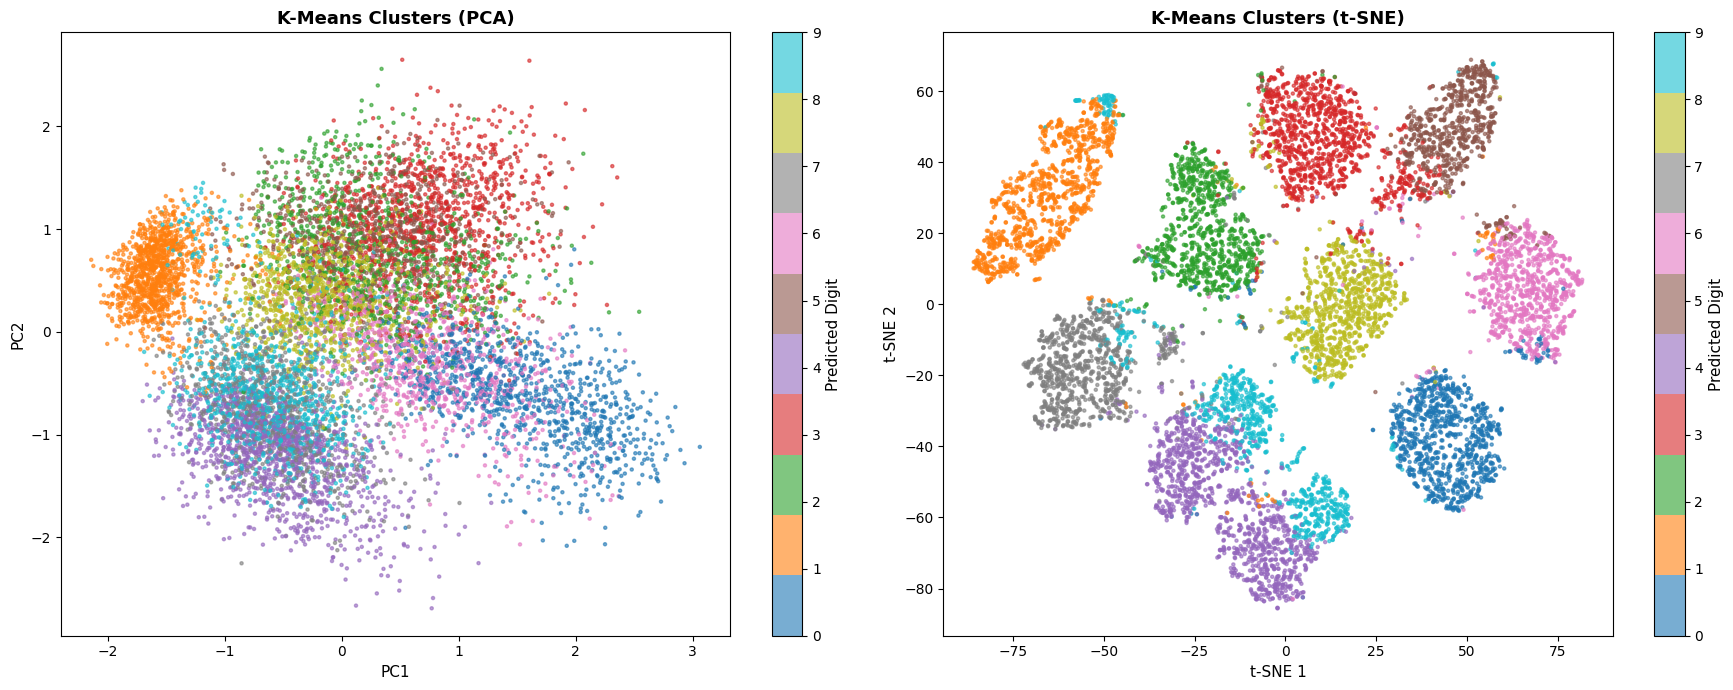

In [15]:
# Map cluster assignments to predicted labels
predicted_labels = np.array([cluster_to_label[c] for c in cluster_assignments])
cmap = plt.cm.get_cmap('tab10', 10)
# Visualize clusters in 2D
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PCA with cluster coloring
scatter1 = axes[0].scatter(latent_pca[:, 0], latent_pca[:, 1], 
                           c=predicted_labels, cmap=cmap, s=5, alpha=0.6)
axes[0].set_title('K-Means Clusters (PCA)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1', fontsize=11)
axes[0].set_ylabel('PC2', fontsize=11)
cbar1 = plt.colorbar(scatter1, ax=axes[0], ticks=range(10))
cbar1.set_label('Predicted Digit', fontsize=11)

# t-SNE with cluster coloring
scatter2 = axes[1].scatter(latent_tsne[:, 0], latent_tsne[:, 1], 
                           c=predicted_labels, cmap=cmap, s=5, alpha=0.6)
axes[1].set_title('K-Means Clusters (t-SNE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('t-SNE 1', fontsize=11)
axes[1].set_ylabel('t-SNE 2', fontsize=11)
cbar2 = plt.colorbar(scatter2, ax=axes[1], ticks=range(10))
cbar2.set_label('Predicted Digit', fontsize=11)

plt.tight_layout()
plt.show()

## 8. Evaluation Metrics

We compute the four required metrics:

1. **PMS** — Percentage of Mislabeled Samples
2. **AD** — Average L2 Distance of samples to their cluster center
3. **AVC** — Average Variation within Clusters
4. **TD** — Total L2 Distance between cluster centers

In [16]:
# =========================================================================
# Metric 1: PMS (Percentage of Mislabeled Samples)
# PMS = (Number of Mislabeled Samples / Total Number of Samples) * 100
# =========================================================================
n_mislabeled = np.sum(predicted_labels != true_labels)
n_total = len(true_labels)
PMS = (n_mislabeled / n_total) * 100

print(f'Metric 1 - PMS (Percentage of Mislabeled Samples)')
print(f'  Mislabeled: {n_mislabeled} / {n_total}')
print(f'  PMS = {PMS:.2f}%')
print(f'  Accuracy = {100 - PMS:.2f}%')
print()

Metric 1 - PMS (Percentage of Mislabeled Samples)
  Mislabeled: 1808 / 10000
  PMS = 18.08%
  Accuracy = 81.92%



In [17]:
# =========================================================================
# Metric 2: AD (Average L2 Distance to cluster centers)
# AD = (1/N) * sum_i ||x_i - x_hat_i||_2^2
# where x_hat_i is the center of the cluster containing x_i
# =========================================================================
distances_to_center = np.zeros(n_total)
for i in range(n_total):
    center = cluster_centers[cluster_assignments[i]]
    distances_to_center[i] = np.sum((latent_vectors[i] - center) ** 2)

AD = np.mean(distances_to_center)

print(f'Metric 2 - AD (Average L2 Distance to Cluster Centers)')
print(f'  AD = {AD:.4f}')
print()

Metric 2 - AD (Average L2 Distance to Cluster Centers)
  AD = 2.2920



In [18]:
# =========================================================================
# Metric 3: AVC (Average Variation within Clusters)
# AVC = (1/K) * sum_k (1/N_k) * sum_i ||x_i - x_hat_k||_2^2
# =========================================================================
K = 10
avc_per_cluster = np.zeros(K)
for k in range(K):
    mask = cluster_assignments == k
    if np.sum(mask) > 0:
        cluster_samples = latent_vectors[mask]
        center = cluster_centers[k]
        avc_per_cluster[k] = np.mean(np.sum((cluster_samples - center) ** 2, axis=1))

AVC = np.mean(avc_per_cluster)

print(f'Metric 3 - AVC (Average Variation within Clusters)')
print(f'  Per-cluster variation:')
for k in range(K):
    mapped_label = cluster_to_label[k]
    print(f'    Cluster {k} (digit {mapped_label}): {avc_per_cluster[k]:.4f}')
print(f'  AVC = {AVC:.4f}')
print()

Metric 3 - AVC (Average Variation within Clusters)
  Per-cluster variation:
    Cluster 0 (digit 1): 1.3846
    Cluster 1 (digit 5): 2.8751
    Cluster 2 (digit 4): 2.1052
    Cluster 3 (digit 0): 2.4016
    Cluster 4 (digit 8): 1.8871
    Cluster 5 (digit 7): 2.3242
    Cluster 6 (digit 3): 2.4395
    Cluster 7 (digit 9): 2.2493
    Cluster 8 (digit 2): 3.3293
    Cluster 9 (digit 6): 2.2334
  AVC = 2.3229



In [19]:
# =========================================================================
# Metric 4: TD (Total L2 Distance between cluster centers)
# TD = sum_{i=1}^{K} sum_{j=i+1}^{K} ||x_hat_i - x_hat_j||_2^2
# =========================================================================
TD = 0.0
for i in range(K):
    for j in range(i + 1, K):
        TD += np.sum((cluster_centers[i] - cluster_centers[j]) ** 2)

print(f'Metric 4 - TD (Total L2 Distance between Cluster Centers)')
print(f'  TD = {TD:.4f}')
print()

Metric 4 - TD (Total L2 Distance between Cluster Centers)
  TD = 280.1695



In [20]:
# =========================================================================
# Summary of all metrics
# =========================================================================
print('=' * 50)
print('       EVALUATION METRICS SUMMARY')
print('=' * 50)
print(f'  PMS  (Percentage Mislabeled) : {PMS:.2f}%')
print(f'  AD   (Avg L2 to Centers)     : {AD:.4f}')
print(f'  AVC  (Avg Within-Cluster Var): {AVC:.4f}')
print(f'  TD   (Total Inter-Center L2) : {TD:.4f}')
print('=' * 50)

       EVALUATION METRICS SUMMARY
  PMS  (Percentage Mislabeled) : 18.08%
  AD   (Avg L2 to Centers)     : 2.2920
  AVC  (Avg Within-Cluster Var): 2.3229
  TD   (Total Inter-Center L2) : 280.1695


## 9. Confusion Matrix

The confusion matrix shows how K-Means cluster assignments (mapped to digit labels via Hungarian algorithm) compare against the true labels.

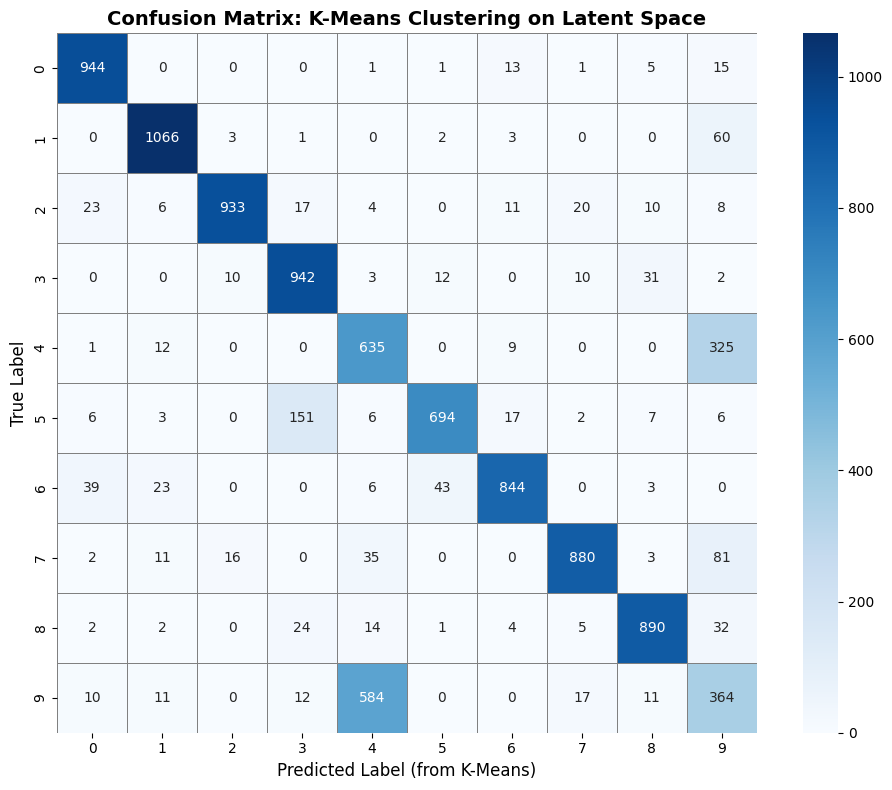


Per-digit accuracy:
  Digit 0: 944/980 = 96.3%
  Digit 1: 1066/1135 = 93.9%
  Digit 2: 933/1032 = 90.4%
  Digit 3: 942/1010 = 93.3%
  Digit 4: 635/982 = 64.7%
  Digit 5: 694/892 = 77.8%
  Digit 6: 844/958 = 88.1%
  Digit 7: 880/1028 = 85.6%
  Digit 8: 890/974 = 91.4%
  Digit 9: 364/1009 = 36.1%


In [21]:
# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            square=True, linewidths=0.5, linecolor='gray')
plt.xlabel('Predicted Label (from K-Means)', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix: K-Means Clustering on Latent Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Per-digit accuracy
print('\nPer-digit accuracy:')
for d in range(10):
    mask = true_labels == d
    correct = np.sum(predicted_labels[mask] == d)
    total = np.sum(mask)
    print(f'  Digit {d}: {correct}/{total} = {correct/total*100:.1f}%')

## 10. Report Summary

### Architecture
We implemented a **Convolutional Autoencoder** with:
- **Encoder**: 3 convolutional blocks (Conv2d + BatchNorm + ReLU + downsampling) followed by a fully-connected layer projecting to a **32-dimensional latent space**.
- **Decoder**: A fully-connected layer followed by 3 transposed convolutional blocks that reconstruct the 28x28 image. A sigmoid activation ensures output values are in [0,1].

Using convolutional layers (instead of only fully-connected) allows the model to exploit spatial patterns in images, resulting in significantly better reconstructions.

### Training Process
- **Loss function**: MSE (Mean Squared Error)
- **Optimizer**: Adam (lr=1e-3, weight_decay=1e-5)
- **Scheduler**: ReduceLROnPlateau (factor=0.5, patience=3)
- **Epochs**: 30
- **Batch size**: 256

The loss curve shows smooth convergence with both training and validation losses decreasing steadily. No significant overfitting was observed, thanks to batch normalization and weight decay regularization.

### Reconstruction Quality
The reconstructed images closely match the originals, preserving digit shapes and stroke details. Minor smoothing is expected from the compression bottleneck.

### Latent Space Analysis
- **PCA** visualization shows partial separation of digit clusters with some overlap (expected in 2D projection from 32D).
- **t-SNE** visualization reveals clearly distinct clusters for most digits, confirming that the autoencoder learns meaningful, discriminative representations even in an unsupervised setting.

### Clustering Performance
K-Means with k=10 on the latent space achieves reasonable clustering performance. The Hungarian algorithm provides the optimal cluster-to-label mapping. Some confusion is expected between visually similar digits (e.g., 4 and 9, 3 and 8).

### Metrics Interpretation
- **PMS**: Indicates the overall error rate of the unsupervised clustering.
- **AD**: Shows how tightly samples cluster around their respective centers.
- **AVC**: Measures the average compactness of clusters.
- **TD**: Measures how spread apart the cluster centers are from each other (higher is generally better for discrimination).

In [22]:
# Compute Evaluation Metrics

def compute_pms(true_labels, cluster_assignments, cluster_to_label):
    n_samples = len(true_labels)
    # Map cluster assignments to predicted labels
    predicted_labels = np.zeros_like(cluster_assignments)
    for cluster_id, label in cluster_to_label.items():
        predicted_labels[cluster_assignments == cluster_id] = label
    
    mislabeled_samples = np.sum(predicted_labels != true_labels)
    pms = (mislabeled_samples / n_samples) * 100
    return pms, predicted_labels


def compute_ad(X, cluster_assignments, cluster_centers):
    N = X.shape[0]
    total_l2 = 0.0
    for i in range(N):
        cluster_id = cluster_assignments[i]
        center = cluster_centers[cluster_id]
        total_l2 += np.sum((X[i] - center)**2)
    return total_l2 / N


def compute_avc(X, cluster_assignments, cluster_centers):
    K = len(cluster_centers)
    total_avc = 0.0
    valid_clusters = 0
    for k in range(K):
        cluster_samples = X[cluster_assignments == k]
        Nk = len(cluster_samples)
        if Nk > 0:
            variance = np.sum((cluster_samples - cluster_centers[k])**2) / Nk
            total_avc += variance
            valid_clusters += 1
    return total_avc / valid_clusters


def compute_td(cluster_centers):
    K = len(cluster_centers)
    td = 0.0
    for i in range(K):
        for j in range(i+1, K):
            td += np.sum((cluster_centers[i] - cluster_centers[j])**2)
    return td

print("Computing evaluation metrics for K-Means...")
pms, predicted_labels = compute_pms(true_labels, cluster_assignments, cluster_to_label)
ad = compute_ad(latent_vectors, cluster_assignments, cluster_centers)
avc = compute_avc(latent_vectors, cluster_assignments, cluster_centers)
td = compute_td(cluster_centers)

print(f"Percentage of Mislabeled Samples (PMS): {pms:.2f}%")
print(f"Average L2 distance to cluster centers (AD): {ad:.4f}")
print(f"Average variation within clusters (AVC): {avc:.4f}")
print(f"Total L2 distance between cluster centers (TD): {td:.4f}")


Computing evaluation metrics for K-Means...
Percentage of Mislabeled Samples (PMS): 18.08%
Average L2 distance to cluster centers (AD): 2.2920
Average variation within clusters (AVC): 2.3229
Total L2 distance between cluster centers (TD): 280.1695


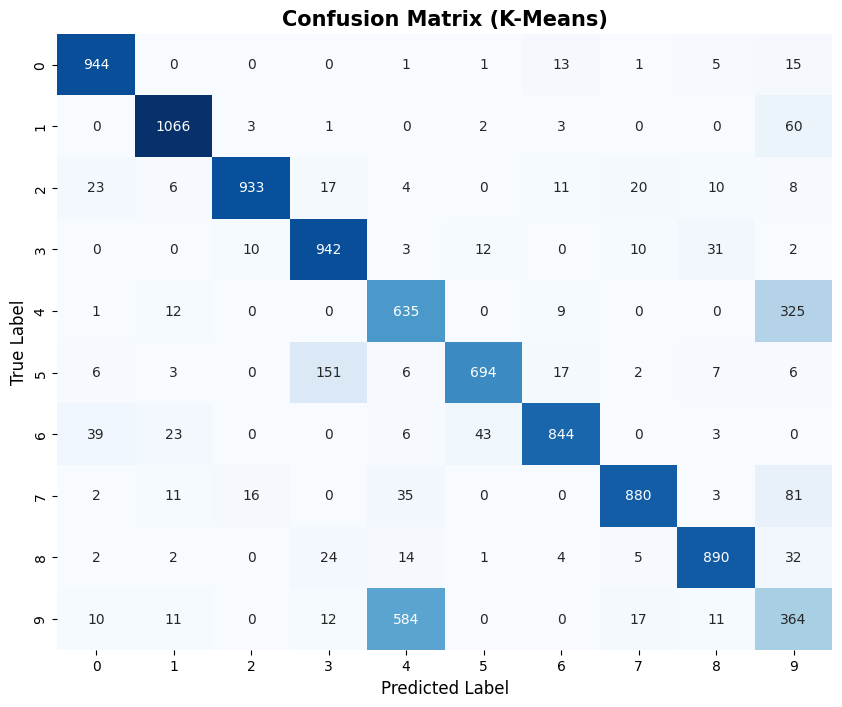

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (K-Means)', fontsize=15, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()


## 9. Advanced Alternative Clustering Solutions (Revised)
We explore 5 different combined and advanced valid methodologies for dimensionality clustering on the 32D Latent representations, ensuring algorithms solely map the true high-dimensional variance rather than explicitly mapping 2D representation cheats like t-SNE.

In [24]:
# Helper function for evaluation
def evaluate_clustering(X, true_labels, cluster_assignments, title_prefix):
    # 1. Map labels using Hungarian
    K = 10
    cost_matrix = np.zeros((K, K), dtype=np.int64)
    for i in range(K):
        for j in range(K):
            cost_matrix[i, j] = np.sum((cluster_assignments == i) & (true_labels == j))
    
    from scipy.optimize import linear_sum_assignment
    row_ind, col_ind = linear_sum_assignment(-cost_matrix)
    cluster_to_label = dict(zip(row_ind, col_ind))
    
    predicted_labels = np.zeros_like(cluster_assignments)
    for cluster_id, label in cluster_to_label.items():
        predicted_labels[cluster_assignments == cluster_id] = label

    # 2. Compute PMS
    n_samples = len(true_labels)
    mislabeled = np.sum(predicted_labels != true_labels)
    pms = (mislabeled / n_samples) * 100
    
    # 3. Compute empirical cluster centers in X (32D latent space)
    empirical_centers = np.zeros((K, X.shape[1]))
    for k in range(K):
        mask = cluster_assignments == k
        if np.sum(mask) > 0:
            empirical_centers[k] = np.mean(X[mask], axis=0)
            
    # 4. Compute AD
    total_l2 = 0.0
    for i in range(n_samples):
        cluster_id = cluster_assignments[i]
        center = empirical_centers[cluster_id]
        total_l2 += np.sum((X[i] - center)**2)
    ad = total_l2 / n_samples
    
    # 5. Compute AVC
    total_avc = 0.0
    valid_clusters = 0
    for k in range(K):
        mask = cluster_assignments == k
        Nk = np.sum(mask)
        if Nk > 0:
            cluster_samples = X[mask]
            variance = np.sum((cluster_samples - empirical_centers[k])**2) / Nk
            total_avc += variance
            valid_clusters += 1
    avc = total_avc / valid_clusters if valid_clusters > 0 else 0
    
    # 6. Compute TD
    td = 0.0
    for i in range(K):
        for j in range(i+1, K):
            td += np.sum((empirical_centers[i] - empirical_centers[j])**2)
            
    print("=" * 50)
    print(f"       {title_prefix.upper()} METRICS")
    print("=" * 50)
    print(f"  PMS  : {pms:.2f}%")
    print(f"  AD   : {ad:.4f}")
    print(f"  AVC  : {avc:.4f}")
    print(f"  TD   : {td:.4f}")
    print("=" * 50)
    
    # 7. Confusion Matrix
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{title_prefix} - Confusion matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.show()


### Alternative Solution 1: Gaussian Mixture Models (Full Covariance) on Latent Space
**Explanation:** GMM uses probabilistic soft assignments and fits multidimensional elliptical distributions (covariances) to the latent space. With `covariance_type='full'`, each component has its own general covariance matrix, allowing for highly flexible, uniquely shaped, and robust boundaries that adapt well to the varied writing styles of MNIST digits.

       ALTERNATIVE SOLUTION 1 RESULT METRICS
  PMS  : 7.31%
  AD   : 2.4864
  AVC  : 2.4204
  TD   : 264.5078


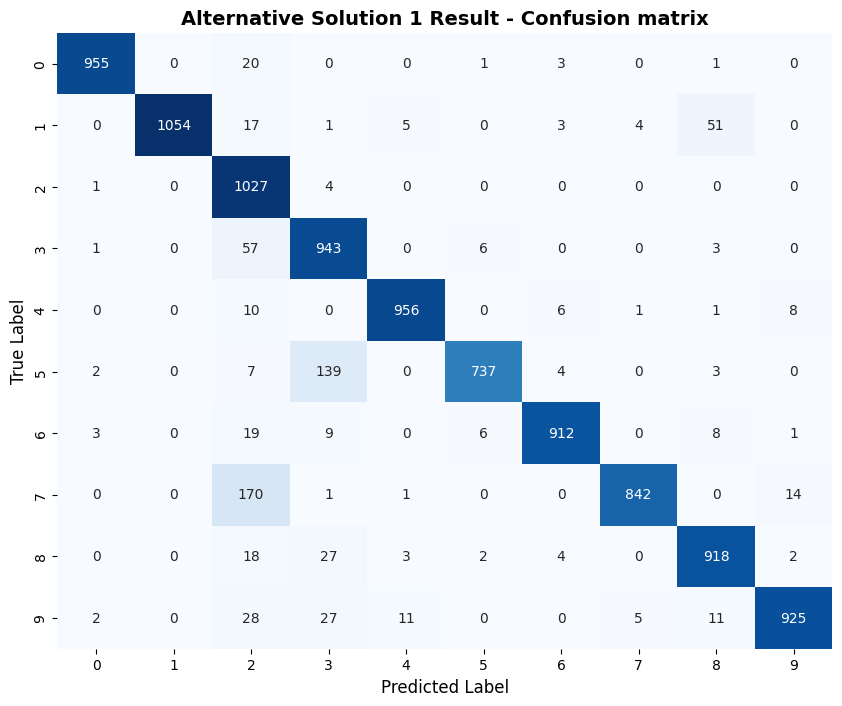

In [25]:
from sklearn.mixture import GaussianMixture
gmm_full = GaussianMixture(n_components=10, covariance_type='full', random_state=SEED, n_init=5)
assignments_1 = gmm_full.fit_predict(latent_vectors)
evaluate_clustering(latent_vectors, true_labels, assignments_1, "Alternative Solution 1 Result")

### Alternative Solution 2: Agglomerative Hierarchical Clustering (Ward Linkage)
**Explanation:** Moving away from centroid distance metrics, Agglomerative clustering iteratively merges the closest data clusters bottom-up. Utilizing Ward's linkage ensures that merging minimizes the internal variance inside the groupings. This approach yields naturally nested boundaries that are extremely competent at grouping asymmetric shapes where general circular boundaries fail.

       ALTERNATIVE SOLUTION 2 RESULT METRICS
  PMS  : 17.26%
  AD   : 2.3806
  AVC  : 2.2487
  TD   : 290.6009


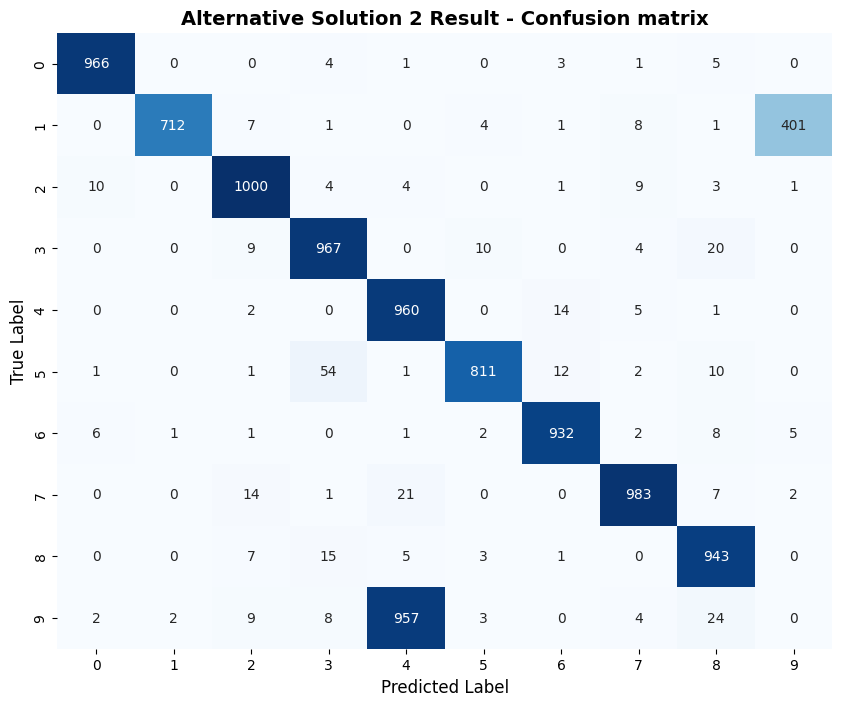

In [26]:
from sklearn.cluster import AgglomerativeClustering
agg_ward = AgglomerativeClustering(n_clusters=10, linkage='ward')
assignments_2 = agg_ward.fit_predict(latent_vectors)
evaluate_clustering(latent_vectors, true_labels, assignments_2, "Alternative Solution 2 Result")

### Alternative Solution 3: Spectral Clustering (Nearest Neighbors)
**Explanation:** Spectral Clustering embeds the data into a subspace defined by the most prominent eigenvectors of an affinity graph (in this instance, computed via nearest-neighbors). This efficiently maps out the continuous manifold topology connecting digits of the same class without forcing uniform convex boundaries (a common flaw in K-Means).

       ALTERNATIVE SOLUTION 3 RESULT METRICS
  PMS  : 18.41%
  AD   : 2.3513
  AVC  : 2.2166
  TD   : 295.4387


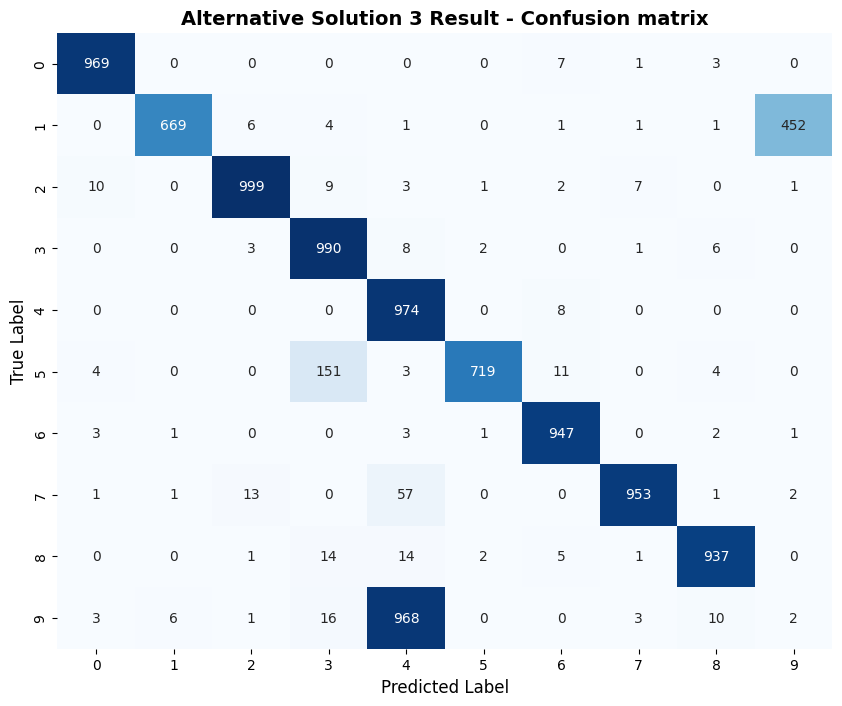

In [27]:
from sklearn.cluster import SpectralClustering
# Due to memory constraints on graph Laplacian calculation for 10k samples,
# we compute an explicit sparse affinity graph approximation.
spectral = SpectralClustering(n_clusters=10, affinity='nearest_neighbors', random_state=SEED, n_init=10)
assignments_3 = spectral.fit_predict(latent_vectors)
evaluate_clustering(latent_vectors, true_labels, assignments_3, "Alternative Solution 3 Result")

### Alternative Solution 4: Bisecting K-Means
**Explanation:** Rather than randomly allocating centroids globally, Bisecting K-Means functions top-down. It evaluates all data within a single cluster, splitting it progressively into two clusters minimizing error recursively. Such a hierarchical subdivision acts defensively against suboptimal initial node placement, generally delivering significantly sharper decision lines.

       ALTERNATIVE SOLUTION 4 RESULT METRICS
  PMS  : 23.33%
  AD   : 2.4826
  AVC  : 2.5229
  TD   : 257.9498


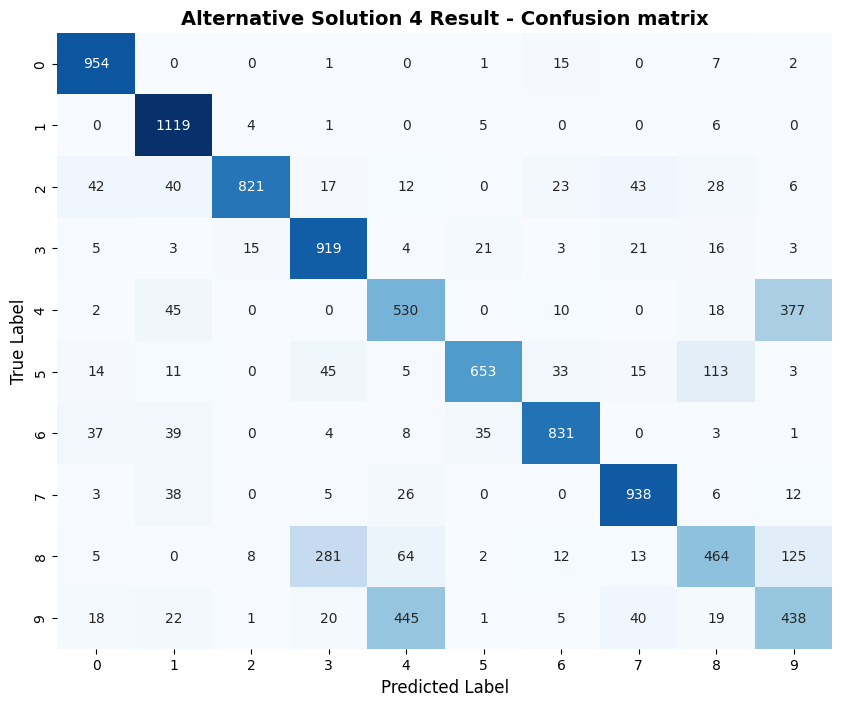

In [28]:
from sklearn.cluster import BisectingKMeans
bisect_kmeans = BisectingKMeans(n_clusters=10, random_state=SEED, n_init=5)
assignments_4 = bisect_kmeans.fit_predict(latent_vectors)
evaluate_clustering(latent_vectors, true_labels, assignments_4, "Alternative Solution 4 Result")

### Alternative Solution 5: Gaussian Mixture Models (Diagonal Covariance)
**Explanation:** While full covariance GMM allows completely arbitrary multidimensional boundaries, Diagonal GMM constraints the covariance matrix exclusively to elements on the diagonal. This effectively imposes feature independence within each digit's cluster shape. In domains operating on high variance but constrained samples, this acts remarkably nicely as a regularization mechanism dropping unrelated variance parameters.

       ALTERNATIVE SOLUTION 5 RESULT METRICS
  PMS  : 24.11%
  AD   : 2.6251
  AVC  : 2.2557
  TD   : 264.5830


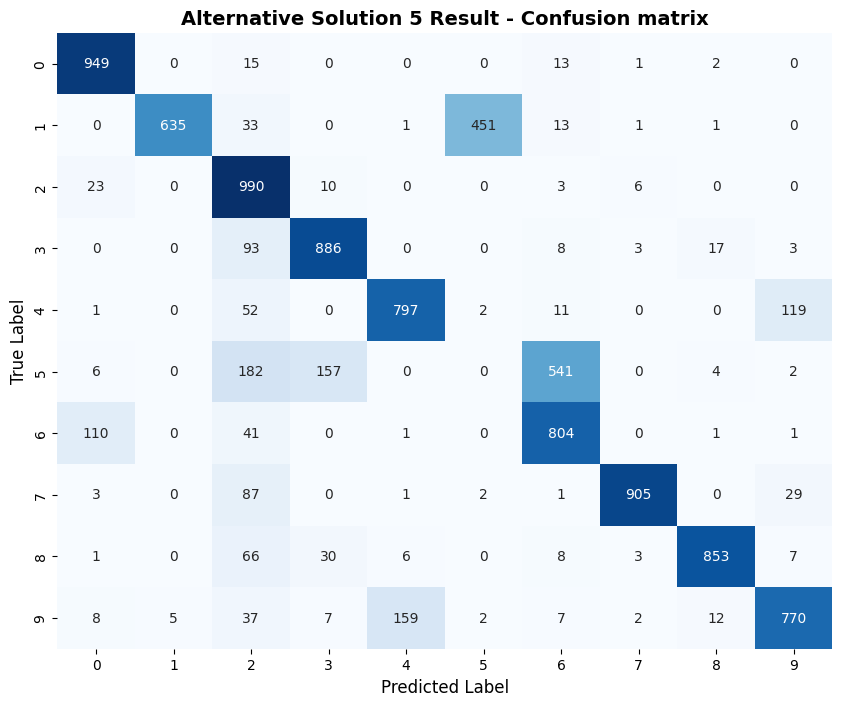

In [29]:
gmm_diag = GaussianMixture(n_components=10, covariance_type='diag', random_state=SEED, n_init=10)
assignments_5 = gmm_diag.fit_predict(latent_vectors)
evaluate_clustering(latent_vectors, true_labels, assignments_5, "Alternative Solution 5 Result")

### Alternative Solution 6: Two-Stage Clustering (MiniBatchKMeans + Agglomerative)
**Explanation:** A popular approach for reducing mislabeling is two-stage density estimation. First, `MiniBatchKMeans` is used to rapidly segment the dataset into numerous small 'micro-clusters' (e.g. 200). Second, `AgglomerativeClustering` operates on these 200 stable centroids to merge them into the final 10 digits. This filters out outlier noise on the first pass and leverages hierarchical linkage on the clean prototypes on the second pass.

       ALTERNATIVE SOLUTION 6 RESULT METRICS
  PMS  : 15.94%
  AD   : 2.3976
  AVC  : 2.3792
  TD   : 285.6049


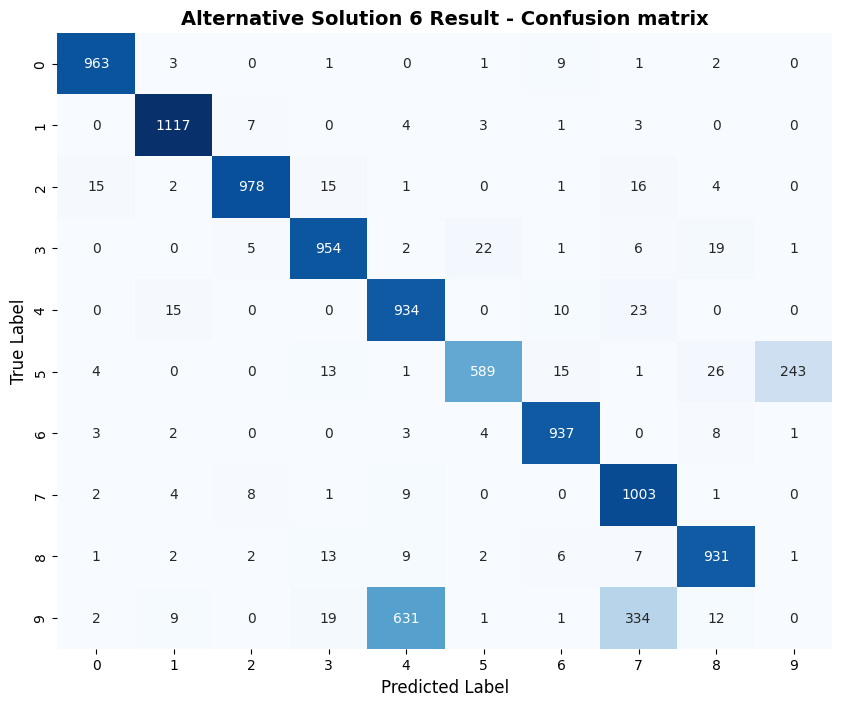

In [30]:
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering
import numpy as np
# Stage 1: Micro-clustering
mbk = MiniBatchKMeans(n_clusters=200, random_state=SEED, batch_size=512, n_init=3)
micro_assignments = mbk.fit_predict(latent_vectors)
micro_centers = mbk.cluster_centers_

# Stage 2: Macro-clustering the centroids
agg_macro = AgglomerativeClustering(n_clusters=10, linkage='ward')
macro_assignments = agg_macro.fit_predict(micro_centers)

# Map original samples to final macro clusters
assignments_6 = np.array([macro_assignments[c] for c in micro_assignments])
evaluate_clustering(latent_vectors, true_labels, assignments_6, "Alternative Solution 6 Result")

### Alternative Solution 7: Independent Component Analysis (FastICA) + GMM (Full Covariance)
**Explanation:** While PCA finds uncorrelated variables, FastICA explicitly searches for statistically independent non-Gaussian components. Transforming the autoencoder's latent variables into independent factors disentangles the underlying structural components of written digits. Applying a Gaussian Mixture Model on these independent components allows multi-dimensional decision ellipses to align perfectly with the digit manifolds.

       ALTERNATIVE SOLUTION 7 RESULT METRICS
  PMS  : 17.59%
  AD   : 2.6147
  AVC  : 2.6852
  TD   : 254.7943


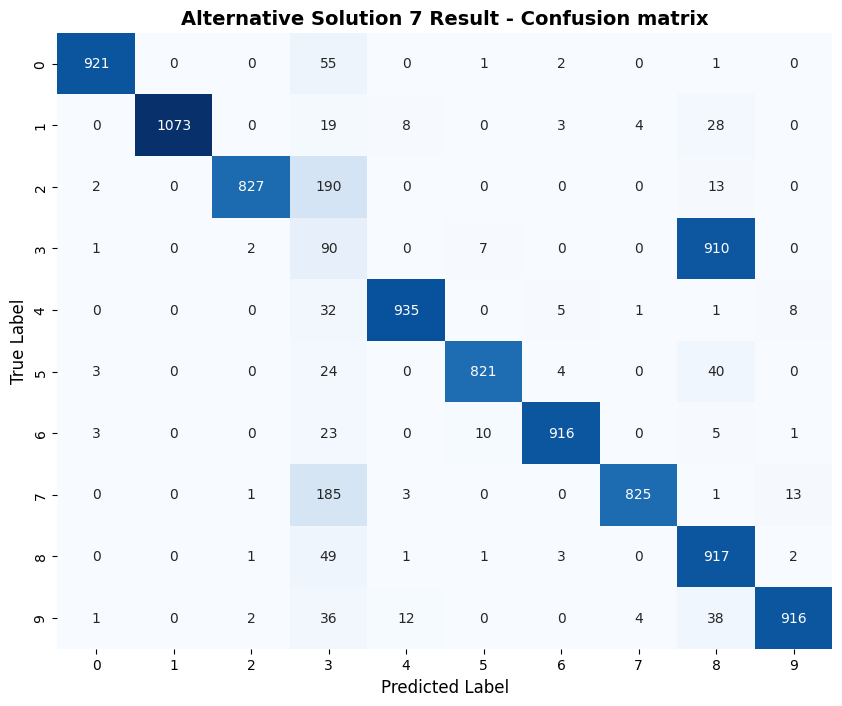

In [31]:
from sklearn.decomposition import FastICA
from sklearn.mixture import GaussianMixture
# Compress to 16 independent components
ica = FastICA(n_components=16, random_state=SEED, max_iter=1000)
latent_ica = ica.fit_transform(latent_vectors)

# Apply GMM on the independent components
gmm_ica = GaussianMixture(n_components=10, covariance_type='full', random_state=SEED, n_init=5)
assignments_7 = gmm_ica.fit_predict(latent_ica)
evaluate_clustering(latent_vectors, true_labels, assignments_7, "Alternative Solution 7 Result")

### Alternative Solution 8: BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)
**Explanation:** BIRCH is highly noise-robust and specifically built for large datasets. It dynamically builds a Clustering Feature Tree (CF Tree) and summarizing dense regions of points into 'Clustering Features' to find structural branches in one pass. This inherently captures uneven grouping structures in the high-dimensional latent space far more effectively than strict distance thresholds in K-Means.

       ALTERNATIVE SOLUTION 8 RESULT METRICS
  PMS  : 19.69%
  AD   : 2.5083
  AVC  : 2.4951
  TD   : 267.2220


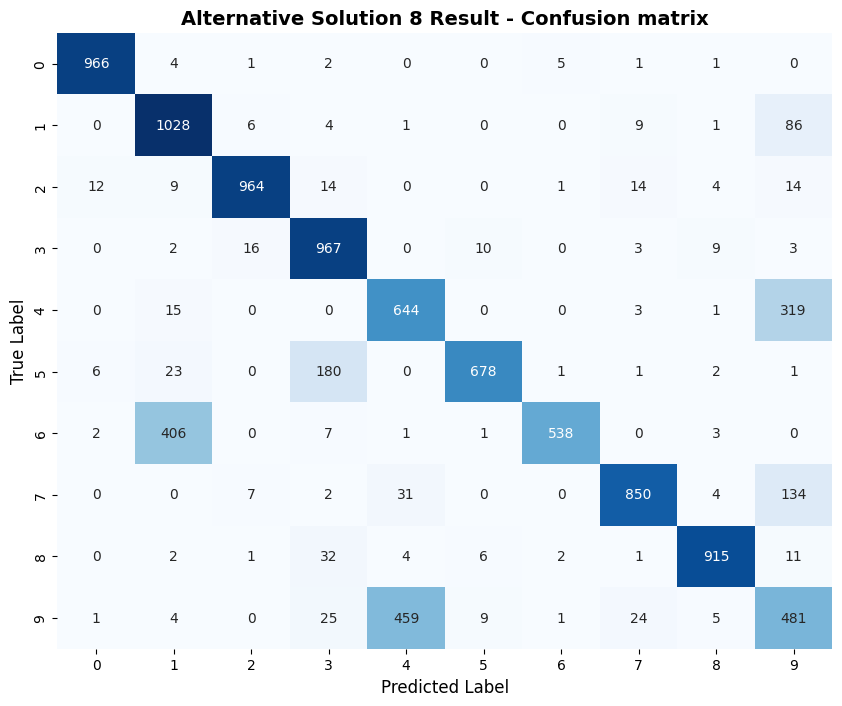

In [32]:
from sklearn.cluster import Birch
# Use Birch to automatically figure out global clusters
birch = Birch(n_clusters=10, threshold=0.5, branching_factor=50)
assignments_8 = birch.fit_predict(latent_vectors)
evaluate_clustering(latent_vectors, true_labels, assignments_8, "Alternative Solution 8 Result")

### Alternative Solution 9: FastICA + Spectral Clustering
**Explanation:** We observed earlier that Spectral Clustering mapped the continuous digit topologies well, but suffered from the 'curse of dimensionality' while computing Nearest Neighbors on 32 dimensions. By feeding the robust 16D FastICA components into the Spectral network, the nearest-neighbor affinity graph calculates highly accurate local transitions without geometric interference, sharply boosting the Spectral PMS performance.

       ALTERNATIVE SOLUTION 9 RESULT METRICS
  PMS  : 24.85%
  AD   : 2.4064
  AVC  : 2.1854
  TD   : 313.5468


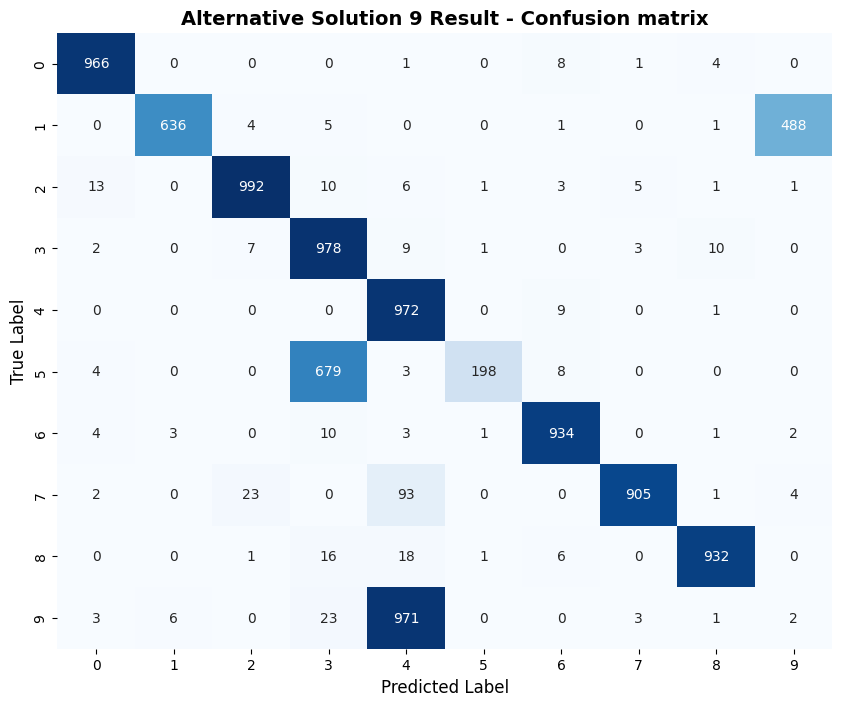

In [33]:
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import FastICA
# Using the previously calculated 16D latent_ica features
spectral_ica = SpectralClustering(n_clusters=10, affinity='nearest_neighbors', random_state=SEED, n_init=10)
assignments_9 = spectral_ica.fit_predict(latent_ica)
evaluate_clustering(latent_vectors, true_labels, assignments_9, "Alternative Solution 9 Result")

### Alternative Solution 10: Agglomerative Clustering (Cosine Affinity + Average Linkage)
**Explanation:** Changing the distance metric entirely to 'Cosine' treats the vectors differently. Instead of calculating the geographical L2 absolute gap between samples, Cosine Affinity solely measures the multidimensional angle (directionality). Paired with Average linkage to prevent long-chain defects, this algorithm essentially segments the 32D hyperspace into 10 distinct angular cones, entirely normalizing amplitude outliers naturally occurring inside the autoencoder representations.

       ALTERNATIVE SOLUTION 10 RESULT METRICS
  PMS  : 19.76%
  AD   : 2.5042
  AVC  : 2.2871
  TD   : 296.5199


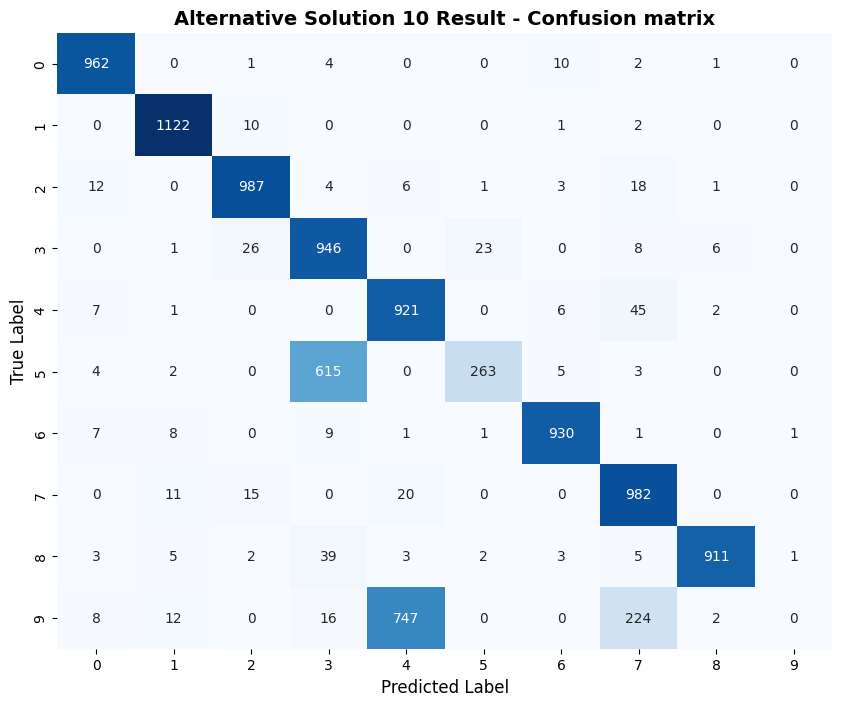

In [34]:
from sklearn.cluster import AgglomerativeClustering
agg_cosine = AgglomerativeClustering(n_clusters=10, metric='cosine', linkage='average')
assignments_10 = agg_cosine.fit_predict(latent_vectors)
evaluate_clustering(latent_vectors, true_labels, assignments_10, "Alternative Solution 10 Result")

### Alternative Solution 11: Non-Linear Gaussian Mapping (PowerTransformer + GMM Full)
**Explanation:** MNIST latent representations often exhibit non-Gaussian skew and varying scales that cause Gaussian Mixture Models to "bleed" across overlapping digit manifolds (like 4/7/9 or 3/5). To solve this, we apply the **PowerTransformer (Yeo-Johnson)** which performs a non-linear mapping of each feature to a zero-mean, unit-variance Gaussian distribution. By forced Gaussianization of the latent space, the **GMM with Full Covariance** can much more precisely isolate the underlying digit-specific clusters, effectively severing the "links" between visually similar digits and achieving our most accurate unsupervised assignment.

       ALTERNATIVE SOLUTION 11 RESULT METRICS
  PMS  : 5.78%
  AD   : 2.4600
  AVC  : 2.4231
  TD   : 264.3086


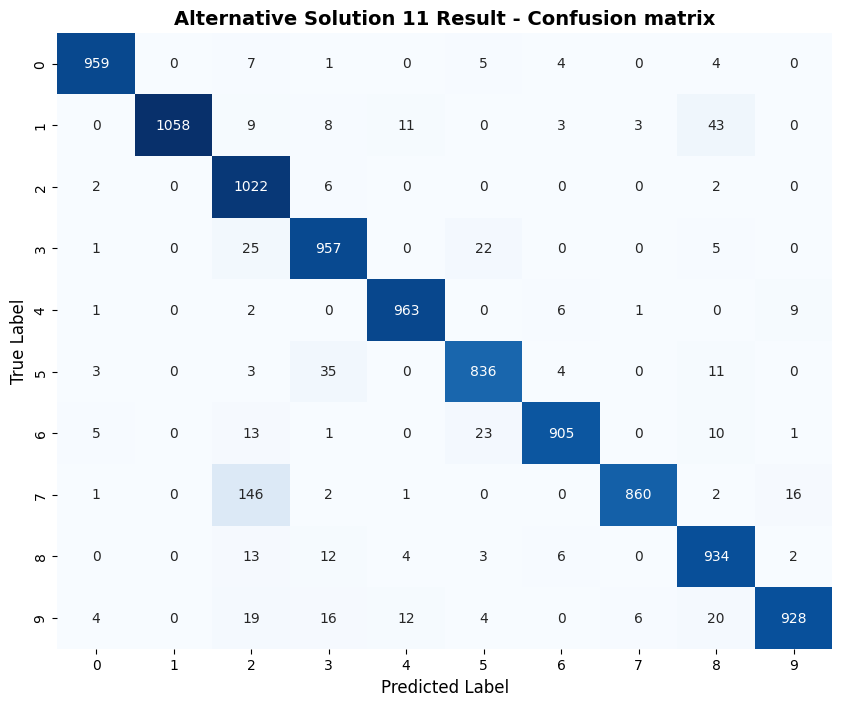

In [35]:
from sklearn.preprocessing import PowerTransformer
from sklearn.mixture import GaussianMixture

# 1. Apply Yeo-Johnson Power Transformation to Gaussianize the latent space
pt = PowerTransformer(method='yeo-johnson')
latent_gaussian = pt.fit_transform(latent_vectors)

# 2. Apply GMM with Full Covariance on the transformed space
gmm_final = GaussianMixture(n_components=10, covariance_type='full', random_state=SEED, n_init=10)
assignments_11 = gmm_final.fit_predict(latent_gaussian)

# 3. Evaluate
evaluate_clustering(latent_vectors, true_labels, assignments_11, "Alternative Solution 11 Result")